# Pipeline 3: The Video Expert

In [38]:
from IPython.display import HTML # to display videos
import base64 # to encode videos as base64
from base64 import b64encode # to encode videos as base64
import os # to interact with the operating system
import subprocess # to run commands
import time # to measure execution time
import csv # to save comments
import uuid # to generate unique ids
import cv2 # to split videos
from PIL import Image # to display videos
import pandas as pd # to display comments
import numpy as np # to use Numerical Python
from io import BytesIO #for a binary stream of data in memory

In [39]:
def download(directory, filename):
    base_url = 'https://raw.githubusercontent.com/Denis2054/RAG-Driven-Generative-AI/main/'

    file_url = f"{base_url}{directory}/{filename}"

    try:

        curl_command = f'curl -o {filename} {file_url}'

        subprocess.run(curl_command, check=True, shell=True)
        print(f"Downloaded '{filename}' successfully.")
    except subprocess.CalledProcessError:
        print(f"Failed to download '{filename}'. Check the URL, your internet connection and the file path")

In [40]:
import os
from dotenv import load_dotenv
load_dotenv()
pinecone_api_key = os.getenv("PINECONE_API_KEY")
pinecone_environment = os.getenv("PINECONE_ENVIRONMENT")

if not pinecone_api_key or not pinecone_environment:
    raise ValueError("Pinecone API key and environment must be set in the .env file.")
else:
    print("Pinecone API key and environment loaded successfully.")

Pinecone API key and environment loaded successfully.


In [41]:
from pinecone import ServerlessSpec

index_name = 'videos-sports-us'
cloud = os.environ.get('PINECONE_CLOUD') or 'aws'
region = os.environ.get('PINECONE_REGION') or 'us-east-1'

spec = ServerlessSpec(cloud=cloud, region=region)

In [42]:
import os
from pinecone import Pinecone, ServerlessSpec

api_key = os.environ.get('PINECONE_API_KEY') or 'PINECONE_API_KEY'

from pinecone import Pinecone, ServerlessSpec
pc = Pinecone(api_key=api_key)

In [43]:
index = pc.Index(index_name)
index.describe_index_stats()

{'dimension': 384,
 'index_fullness': 0.0,
 'namespaces': {'': {'vector_count': 793}},
 'total_vector_count': 793}

### Defining the RAG functions

In [44]:
import time 
from sentence_transformers import SentenceTransformer

embedding_model = "all-MiniLM-L6-v2"


def create_embeddings(chunks, embedding_model):
    model = SentenceTransformer(embedding_model)
    start_time = time.time()
    embeddings = model.encode(chunks, show_progress_bar=True)
    end_time = time.time()
    return embeddings

In [45]:
def query_pinecone(query_text, k):
    query_embedding = create_embeddings([query_text], embedding_model)[0]
    query_embedding = query_embedding.tolist()
    query_results = index.query(vector=query_embedding, top_k=k, include_metadata=True)
    return query_results

In [46]:
def collect_query_results(query_results):
    results = []
    for match in query_results['matches']:
        # Prepare the result dictionary for each match
        result = {
            "ID": match['id'],
            "Score": match['score']
        }

        # Check if metadata is available and add to result dictionary
        if 'metadata' in match:
            metadata = match['metadata']
            result['Text'] = metadata.get('text', "No text metadata available.")
            result['Frame Number'] = metadata.get('frame_number', "No frame number available.")
            result['File Name'] = metadata.get('file_name', "No file name available.")
        else:
            result['Text'] = "No metadata available."
            result['Frame Number'] = "No metadata available."
            result['File Name'] = "No metadata available."

        results.append(result)

    return results

In [59]:
import groq
from llama_index.llms.groq import Groq
import time

client = groq.Client()
model = "llama-3.3-70b-versatile"
start_time = time.time()

def get_response(input_text):
    text_input = '\n'.join(input_text)
    prompt = f"Please elaborate on the following content:\n{text_input}"

    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role":"system","content": "You are an expert in Natural Language Processing exercise professional. In your responses, do NOT cite the context provided after the sentence **augmented input context**"},
                {"role":"assistant", "content": "You must explain and answer in detail to the user query, paying attention to the provided context."},
                {"role":"user", "content": prompt}
            ],
            temperature=0.1
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return str(e)


### Display video

In [48]:
def display_video(file_name):
  with open(file_name, 'rb') as file:
      video_data = file.read()

  video_url = b64encode(video_data).decode()

  html = f'''
  <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{video_url}" type="video/mp4">
  Your browser does not support the video tag.
  </video>
  '''
  HTML(html)
  return HTML(html)

In [49]:
def display_video_frame(file_name, frame_number=0, size=(100, 110)):
    cap = cv2.VideoCapture(file_name)

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

    success, frame = cap.read()
    if not success:
        return "Failed to grab frame"

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    img = Image.fromarray(frame)
    img = img.resize(size, Image.ANTIALIAS)  # Resize image to specified size

    buffered = BytesIO()
    img.save(buffered, format="JPEG")
    img_str = base64.b64encode(buffered.getvalue()).decode()

    html_str = f'''
    <img src="data:image/jpeg;base64,{img_str}" width="{size[0]}" height="{size[1]}">
    '''
    display(HTML(html_str))
    return HTML(html_str)


In [50]:
import os
from IPython.display import Image, display

def display_frame(frame):
    directory = '/content/'  # Adjust the directory if needed
    file_path = os.path.join(directory, frame)

    if os.path.exists(file_path):
        file_size = os.path.getsize(file_path)
        print(f"File '{frame}' exists. Size: {file_size} bytes.")

        logical_size = 1000 
        if file_size > logical_size:
            print("The file size is greater than the logical value.")
            display(Image(filename=file_path))
        else:
            print("The file size is less than or equal to the logical value.")
    else:
        print(f"File '{frame}' does not exist in the specified directory.")

### Querying the vector store


In [51]:
k = 1

In [52]:
query_text = "Find a basketball player that is scoring with a dunk."
query_results = query_pinecone(query_text,k)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [53]:
collected_results = collect_query_results(query_results)

for result in collected_results:
  id= result['ID']
  score= result['Score']
  text= result['Text']
  frame= result['Frame Number']
  file_name= result['File Name']
  print(f"ID={id}")
  print(f"score={score}")
  print(f"text={text}")
  print(f"frame_number={frame}")
  print(f"file_name={file_name}")
  print()  # Add a newline for better readability between entries

ID=f104138b-0be8-4f4c-bf99-86d0eb34f7ee
score=0.734898567
text=In this image, there is a person who appears to be in the process of executing a dunk in basketball. The individual is airborne, with one arm extended upwards towards the basketball hoop, holding a basketball in hand, preparing to slam it through the hoop. The word "dunk" is superimposed on the image, confirming the action taking place. The background shows clear skies and a modern building, suggesting this might be an outdoor basketball court in an urban setting. The player is wearing athletic wear and a pair of basketball shoes, suitable for the sport. The dynamic posture and the context indicate an athletic and powerful movement, typical of a basketball dunk.
frame_number=191
file_name=basketball3.mp4



In [55]:
directory = "Chapter10/videos"
download(directory,file_name)
display_video(file_name)

Failed to download 'basketball3.mp4'. Check the URL, your internet connection and the file path


FileNotFoundError: [Errno 2] No such file or directory: 'basketball3.mp4'

In [56]:
file_name_root = file_name.split('.')[0]
frame="frame_"+str(frame)+".jpg"
print(frame)
directory = "Chapter10/frames/"+file_name_root
print(directory)
download(directory,frame)
display_frame(frame)

frame_191.jpg
Chapter10/frames/basketball3
Failed to download 'frame_191.jpg'. Check the URL, your internet connection and the file path
File 'frame_191.jpg' does not exist in the specified directory.


### Retrieval Augmented Generation

In [57]:
prompt=text

In [60]:
response_content = get_response(prompt)
print(response_content)

The given content appears to be a descriptive passage of a person in the process of executing a dunk in basketball. The individual is airborne, with one arm extended upward toward the basketball hoop, while holding a basketball in their hand. They are wearing athletic attire, including a pair of basketball shoes, which is suitable for the sport.

The background of the image suggests an outdoor or urban setting, with clear skies and a modern building visible. This implies that the scene is taking place in an outdoor basketball court, possibly in an urban environment.

The dynamic posture and the context of the scene indicate a powerful and athletic movement, which is characteristic of a dunk in basketball. The dunk is a high-flying maneuver where a player jumps high and scores by forcefully putting the ball through the hoop. This action requires a combination of strength, agility, and technique, making it an impressive and exciting play in the sport.

The description also highlights the

# Evaluator

In [61]:
!pip install spacy

  Attempting uninstall: typer
    Found existing installation: typer 0.21.2
    Uninstalling typer-0.21.2:
      Successfully uninstalled typer-0.21.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
docling 2.88.0 requires typer<0.22.0,>=0.12.5, but you have typer 0.24.1 which is incompatible.


In [62]:
!python -m spacy download en_core_web_md

     ---------------------------------------- 0.0/33.5 MB ? eta -:--:--
      --------------------------------------- 0.8/33.5 MB 35.0 MB/s eta 0:00:01
     ------------- ------------------------- 11.8/33.5 MB 49.3 MB/s eta 0:00:01
     -------------------------- ------------ 22.8/33.5 MB 49.8 MB/s eta 0:00:01
     ------------------------------- ------- 27.0/33.5 MB 40.8 MB/s eta 0:00:01
     ------------------------------------ -- 31.7/33.5 MB 36.6 MB/s eta 0:00:01
     ---------------------------------------- 33.5/33.5 MB 34.3 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [63]:
!pip install sentence-transformers==3.0.1

   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   -------------------------- ------------- 7.9/12.0 MB 40.7 MB/s eta 0:00:01
   ---------------------------------------- 12.0/12.0 MB 35.8 MB/s  0:00:00
   ---------------------------------------- 0.0/566.4 kB ? eta -:--:--
   ---------------------------------------- 566.4/566.4 kB 19.0 MB/s  0:00:00

  Attempting uninstall: huggingface-hub

    Found existing installation: huggingface_hub 1.10.2

    Uninstalling huggingface_hub-1.10.2:

      Successfully uninstalled huggingface_hub-1.10.2

   ---------------------------------------- 0/3 [huggingface-hub]
   ---------------------------------------- 0/3 [huggingface-hub]
   ---------------------------------------- 0/3 [huggingface-hub]
   ---------------------------------------- 0/3 [huggingface-hub]
   ---------------------------------------- 0/3 [huggingface-hub]
   ---------------------------------------- 0/3 [huggingface-hub]
   --------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
docling 2.88.0 requires typer<0.22.0,>=0.12.5, but you have typer 0.24.1 which is incompatible.


In [64]:
from sentence_transformers import SentenceTransformer
from torch import cosine_similarity
model = SentenceTransformer('all-MiniLM-L6-v2')

def calculate_cosine_similarity_with_embeddings(text1, text2):
    embeddings1 = model.encode(text1)
    embeddings2 = model.encode(text2)
    similarity = cosine_similarity([embeddings1], [embeddings2])
    return similarity[0][0]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [65]:
import spacy

def spacy_similarity(text1, text2):
    nlp = spacy.load('en_core_web_md')

    doc1 = nlp(text1)
    doc2 = nlp(text2)

    similarity_score = doc1.similarity(doc2)

    return similarity_score

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def calculate_cosine_similarity(text1, text2):
    vectorizer = TfidfVectorizer()
    tfidf = vectorizer.fit_transform([text1, text2])
    similarity = cosine_similarity(tfidf[0:1], tfidf[1:2])
    return similarity[0][0]

In [67]:
text1 = " In this image, a basketball player is captured mid-air, executing a powerful dunk. With one arm extended towards the hoop and the basketball firmly in hand, the athlete is poised to slam the ball through the net. The player's athletic wear and basketball shoes highlight their readiness for the sport. The urban outdoor court setting adds to the dynamic and energetic atmosphere of the scene."
text2 = "In this image, a basketball player is shown making a super cool dunk in mid-air."
similarity_score1 = calculate_cosine_similarity(text1, text2)
print(f"Cosine Similarity Score with sklearn: {similarity_score1:.3f}")

similarity_score2 = spacy_similarity(text1, text2)
print(f"Semantic Similarity Score with spaCy: {similarity_score2:.3f}")

similarity_score3=calculate_cosine_similarity_with_embeddings(text1, text2)
print(f"Cosine Similarity Score with sentence transformer: {similarity_score3:.3f}")

similarity_score4 = 0.75
print(f"Cosine Similarity Score with human feedback: {similarity_score4:.3f}")

Cosine Similarity Score with sklearn: 0.201
Semantic Similarity Score with spaCy: 0.941
Cosine Similarity Score with sentence transformer: 0.797
Cosine Similarity Score with human feedback: 0.750


In [68]:
def extract_rewritten_comment(response):
    """
    Extracts the rewritten comment from GPT-4o response.
    """
    lines = response.split('\n')
    rewritten_comment = []
    rewrite_started = False
    for line in lines:
        if "Rewritten Comment:" in line:
            rewrite_started = True
            continue
        if rewrite_started:
            if line.strip() == "":
                break
            rewritten_comment.append(line.strip())
    return " ".join(rewritten_comment)

### Examples

In [69]:
import numpy as np
import sys
rscores =[]

scores=[]

### 1

In [70]:
query_text = "Find a female soccer player that is playing."
import io
old_stdout = sys.stdout
new_stdout = io.StringIO()
sys.stdout = new_stdout
query_results = query_pinecone(query_text,1) # query, k
sys.stdout = old_stdout

collected_results = collect_query_results(query_results)

for result in collected_results:
  id= result['ID']
  score= result['Score']
  text= result['Text']
  frame= result['Frame Number']
  file_name= result['File Name']
  print(f"ID={id}")
  print(f"score={score}")
  print(f"text={text}")
  print(f"frame_number={frame}")
  print(f"file_name={file_name}")
  print()  # Add a newline for better readability between entries
response_content = get_response(text)
print(response_content)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

ID=4cbd9a4c-d08c-4e12-bda6-91849b538f6c
score=0.655511856
text=In the image, there is a person playing a sport, which appears to be soccer, given the soccer net in the background. The person is wearing a red sports uniform and has long brown hair. It seems like they are in the midst of throwing a soccer ball into play, likely performing a throw-in, which is a method of restarting play in a game of soccer after the ball has gone out of the sidelines. The expression on their face suggests that they are energetically engaged in the game. There is a text overlay on the image that reads "female," possibly indicating an automated image tagging or recognition feature that has identified the person as female.
frame_number=131
file_name=female_player_after_scoring.mp4

Object of type SentenceTransformer is not JSON serializable


In [71]:
directory = "Chapter10/videos"
download(directory,file_name)
print("Displaying video: ",file_name)
display_video(file_name)

Failed to download 'female_player_after_scoring.mp4'. Check the URL, your internet connection and the file path
Displaying video:  female_player_after_scoring.mp4


FileNotFoundError: [Errno 2] No such file or directory: 'female_player_after_scoring.mp4'

In [72]:
text1 = "This image shows soccer players on a field dribbling and passing the ball."

text2 = extract_rewritten_comment(response_content)

print(f"Human Feedback Comment: {text1}")
print(f"Rewritten Comment: {text2}")

similarity_score3=calculate_cosine_similarity_with_embeddings(text1, text2)
print(f"Cosine Similarity Score with sentence transformer: {similarity_score3:.3f}")
scores.append(similarity_score3)
rscores.append(score)

Human Feedback Comment: This image shows soccer players on a field dribbling and passing the ball.
Rewritten Comment: 
Cosine Similarity Score with sentence transformer: 0.107


### 2

In [73]:
query_text = "Find a basketball player scoring with a slam dunk."
old_stdout = sys.stdout
new_stdout = io.StringIO()
sys.stdout = new_stdout
query_results = query_pinecone(query_text,1) # query, k
sys.stdout = old_stdout

collected_results = collect_query_results(query_results)

for result in collected_results:
  id= result['ID']
  score= result['Score']
  text= result['Text']
  frame= result['Frame Number']
  file_name= result['File Name']
  print(f"ID={id}")
  print(f"score={score}")
  print(f"text={text}")
  print(f"frame_number={frame}")
  print(f"file_name={file_name}")
  print()  # Add a newline for better readability between entries
response_content = get_response(text)
print(response_content)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

ID=aa7c6c4f-62ff-4166-ba2e-6623a07cd645
score=0.674768507
text=In the image, there is a person performing a slam dunk in basketball. The person is airborne, near the peak of their jump, with one arm extended towards the basketball hoop to score. The word "slam" visible in the image suggests a focus on the slam dunk action. The background features clear skies and a tall building, indicating the setting is likely an outdoor basketball court.
frame_number=179
file_name=basketball3.mp4

Object of type SentenceTransformer is not JSON serializable


In [ ]:
directory = "Chapter10/videos"
download(directory,file_name)
display_video(file_name)

In [74]:
text1 = "This image shows an incredible dunk by a basketball player."

text2 = extract_rewritten_comment(response_content)

print(f"Human Feedback Comment: {text1}")
print(f"Rewritten Comment: {text2}")

similarity_score3=calculate_cosine_similarity_with_embeddings(text1, text2)
print(f"Cosine Similarity Score with sentence transformer: {similarity_score3:.3f}")
scores.append(similarity_score3)
rscores.append(score)

Human Feedback Comment: This image shows an incredible dunk by a basketball player.
Rewritten Comment: 
Cosine Similarity Score with sentence transformer: 0.162


### Metrics calculation and display

In [75]:
print(len(scores), scores)
print(len(rscores), rscores)

2 [0.107013434, 0.16226545]
2 [0.655511856, 0.674768507]


In [76]:
mean_score = np.mean(scores)
median_score = np.median(scores)
std_deviation = np.std(scores)
variance = np.var(scores)
min_score = np.min(scores)
max_score = np.max(scores)
range_score = max_score - min_score
percentile_25 = np.percentile(scores, 25)
percentile_75 = np.percentile(scores, 75)
iqr = percentile_75 - percentile_25

print(f"Mean: {mean_score:.2f}")
print(f"Median: {median_score:.2f}")
print(f"Standard Deviation: {std_deviation:.2f}")
print(f"Variance: {variance:.2f}")
print(f"Minimum: {min_score:.2f}")
print(f"Maximum: {max_score:.2f}")
print(f"Range: {range_score:.2f}")
print(f"25th Percentile (Q1): {percentile_25:.2f}")
print(f"75th Percentile (Q3): {percentile_75:.2f}")
print(f"Interquartile Range (IQR): {iqr:.2f}")

Mean: 0.13
Median: 0.13
Standard Deviation: 0.03
Variance: 0.00
Minimum: 0.11
Maximum: 0.16
Range: 0.06
25th Percentile (Q1): 0.12
75th Percentile (Q3): 0.15
Interquartile Range (IQR): 0.03


In [77]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

scores = np.array(scores)
rscores = np.array(rscores)

assert len(scores) == len(rscores), "Length of scores and rscores must be equal"

threshold = 0.6

true_labels = (rscores > threshold).astype(int)
predicted_labels = (scores > threshold).astype(int)

f1 = f1_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
accuracy = accuracy_score(true_labels, predicted_labels)

print(f"F1 Score: {f1:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"Accuracy: {accuracy:.2f}")

F1 Score: 0.00
Precision: 0.00
Recall: 0.00
Accuracy: 0.00


c:\Users\dorot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


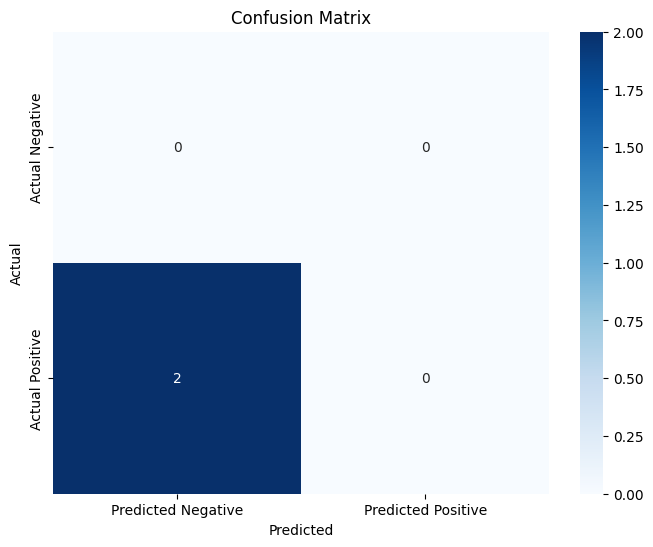

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()